## Importing all of our Third-Party Libraries we need to work with

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

## Let us load our Data

In [2]:
import os

os.chdir(r"D:\class data\Class coding")
print(os.getcwd())

D:\class data\Class coding


In [3]:
sheets = pd.read_excel('TechCorp_Cleaned.xlsx', sheet_name=None)
emp    = sheets['Employees']
dept   = sheets['Departments']
prod   = sheets['Products']
sales  = sheets['Sales']

## 1. plot() Function

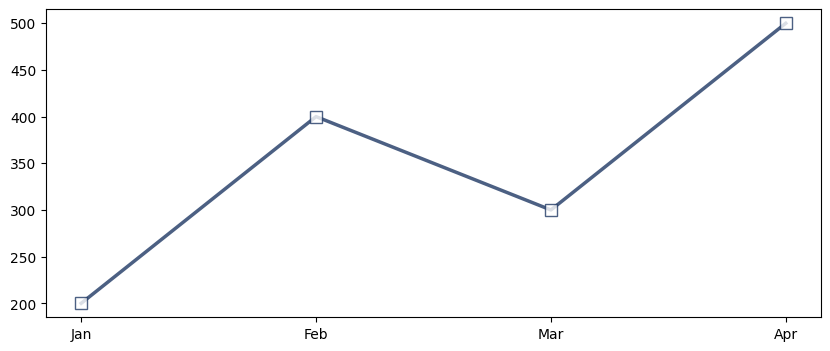

In [4]:
fig,ax = plt.subplots(figsize=(10,4))
ax.plot(['Jan', 'Feb', 'Mar', 'Apr'], [200, 400, 300, 500]
        , color      = '#1F3864',     # navy line
    linewidth  = 2.5,           # thicker line
    linestyle  = '-',           # solid
    marker     = 's',           # circle at each data point
    markersize = 8,
    markerfacecolor = 'white',  # hollow-looking dot
    markeredgecolor = '#1F3864',
    alpha      = 0.8,           # slightly transparent
    label      = 'Monthly Revenue')

## 2. subplot() Function

In [5]:
simple_data = pd.merge(emp, dept, how='left', left_on='department', right_on='department_name')
merged_data = pd.merge(emp, dept, how='left', left_on='department', right_on='department_name').groupby('department')['salary'].mean().reset_index().sort_index()

In [6]:
merged_data.sort_values(by='salary', ascending=False)

,department,salary
2,Finance,106674.741389
4,Marketing,101631.974118
1,Engineering,99261.368000
0,Customer Support,96917.138158
3,HR,93901.705882
5,Sales,90780.636667


In [7]:
emp['department'].value_counts().values

array([25, 24, 19, 18, 17, 17])

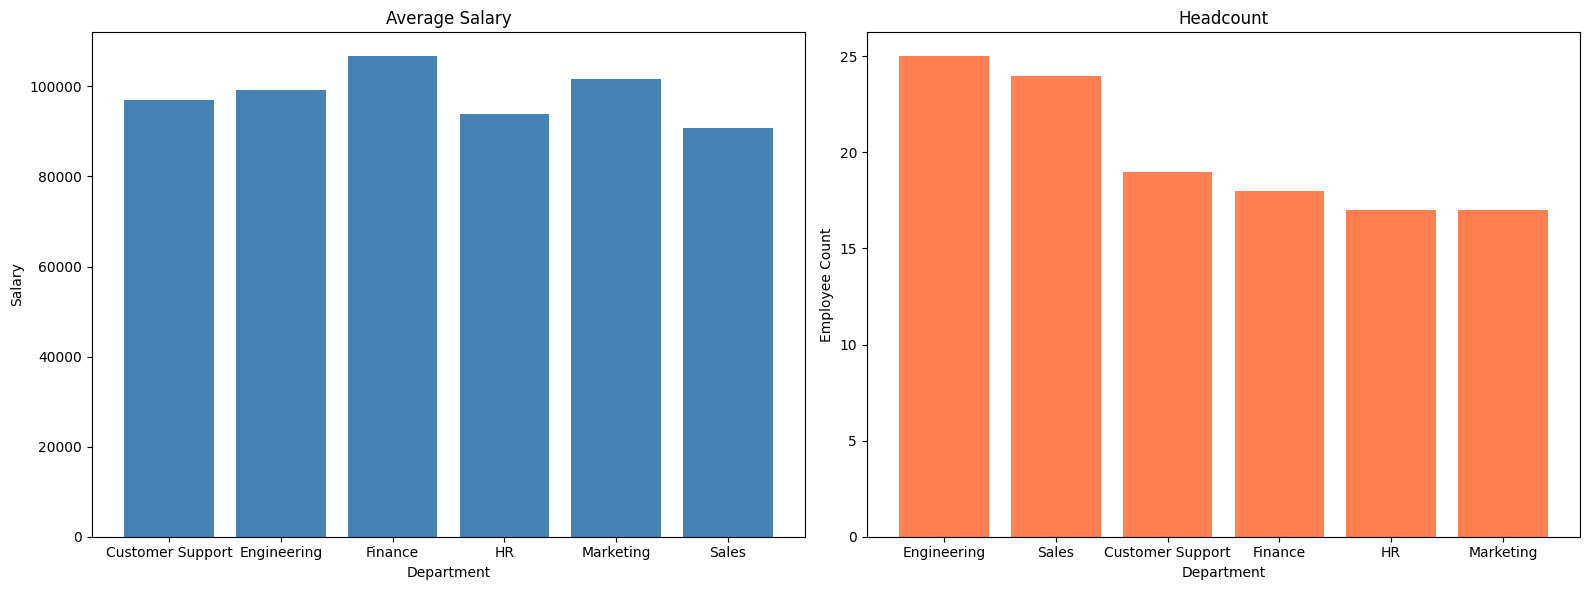

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.bar(merged_data['department'], merged_data['salary'], color='steelblue')
ax1.set_title('Average Salary')
ax1.set_ylabel('Salary')
ax1.set_xlabel('Department')

ax2.bar(emp['department'].value_counts().index, emp['department'].value_counts().values, color='coral')
ax2.set_title('Headcount')
ax2.set_ylabel('Employee Count')
ax2.set_xlabel('Department')

plt.tight_layout()
plt.show()

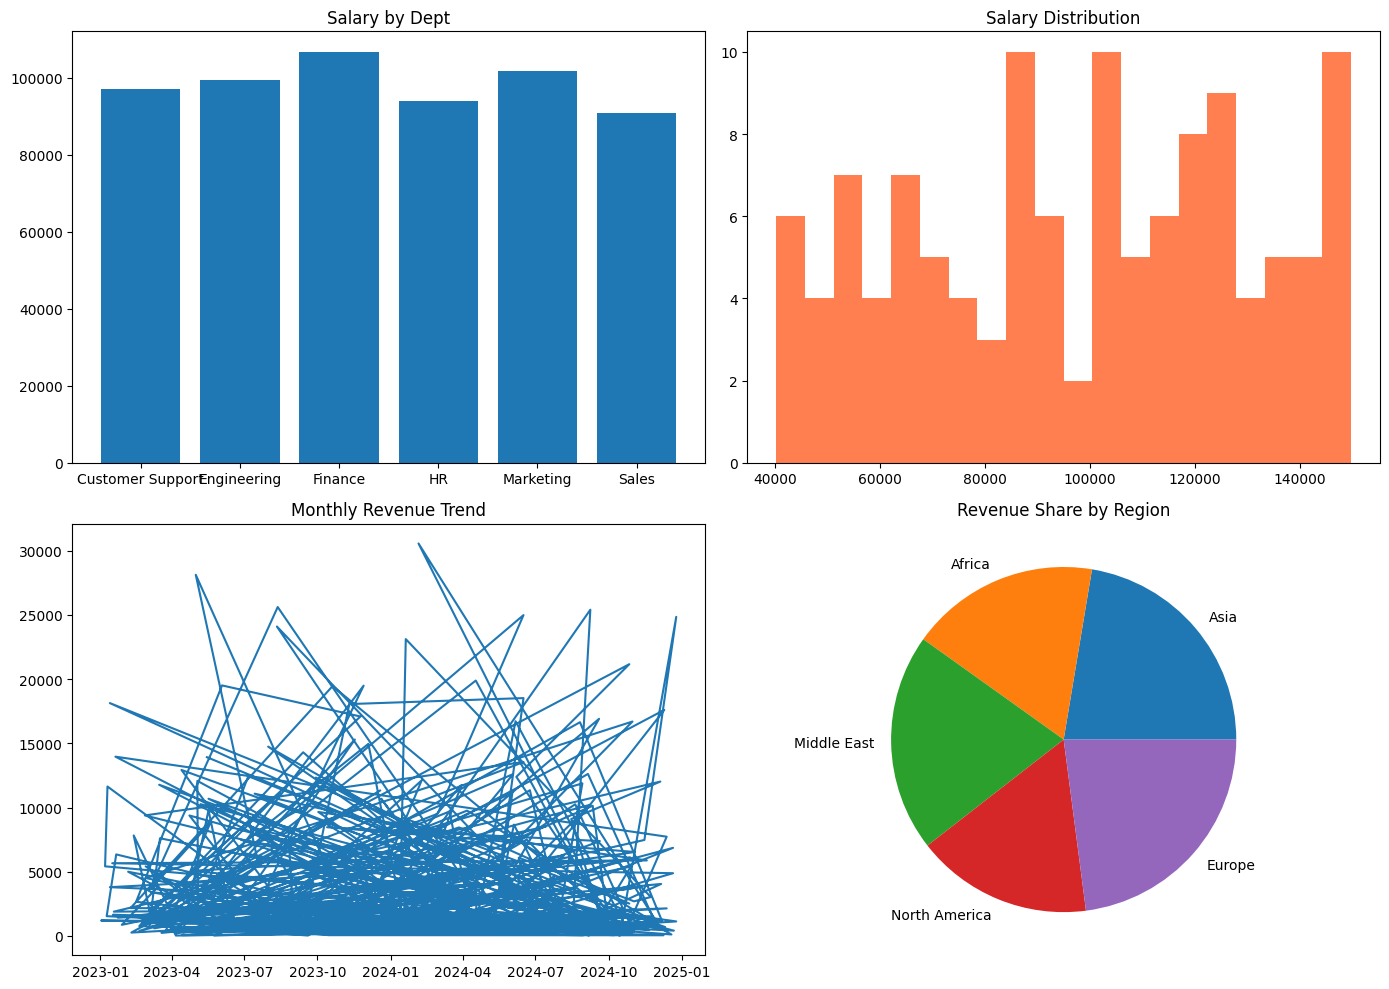

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0][0].bar(merged_data['department'], merged_data['salary'])
axes[0][0].set_title('Salary by Dept')

axes[0][1].hist(emp['salary'], bins=20, color='coral')
axes[0][1].set_title('Salary Distribution')

axes[1][0].plot(sales['date'], sales['total_revenue'])
axes[1][0].set_title('Monthly Revenue Trend')

axes[1][1].pie(sales.groupby('region')['total_revenue'].sum(),
               labels=sales['region'].unique())
axes[1][1].set_title('Revenue Share by Region')

plt.tight_layout()
plt.show()

## fig.savefig() Function

C:\Users\hp\AppData\Local\Temp\ipykernel_19628\2976233956.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(merged_data['department'], color='black', rotation=45)


[Text(0, 0, 'Customer Support'),
 Text(1, 0, 'Engineering'),
 Text(2, 0, 'Finance'),
 Text(3, 0, 'HR'),
 Text(4, 0, 'Marketing'),
 Text(5, 0, 'Sales')]

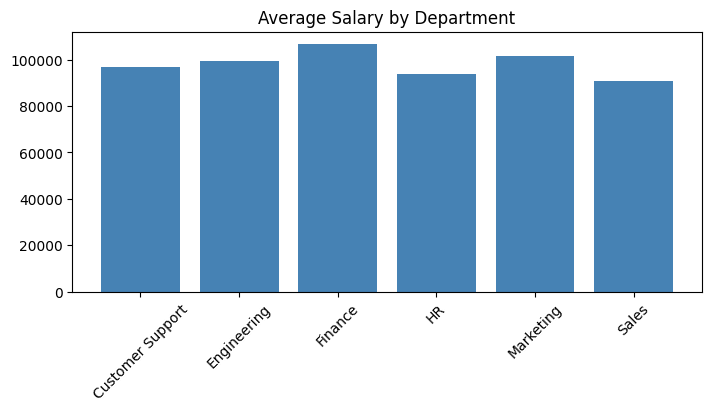

In [10]:
fig, ax = plt.subplots(figsize=(7, 4), constrained_layout=True)
ax.bar(merged_data['department'], merged_data['salary'], color='steelblue')
ax.set_title('Average Salary by Department')
ax.set_xticklabels(merged_data['department'], color='black', rotation=45)



In [11]:
# Step 1 — bare minimum
# fig.savefig(fname='avg_v3.pdf', bbox_inches="tight", pad_inches=0.8, dpi=300)

# Let us Explore different Charts in Matplotlib

**1. Line Chart:**

In [12]:
monthly = (sales.groupby(['sale_year', 'sale_month'])['total_revenue']
                .sum()
                .reset_index()
                .sort_values(['sale_year', 'sale_month']))



In [13]:
rev_2023 = monthly[monthly['sale_year'] == 2023]
rev_2024 = monthly[monthly['sale_year'] == 2024]

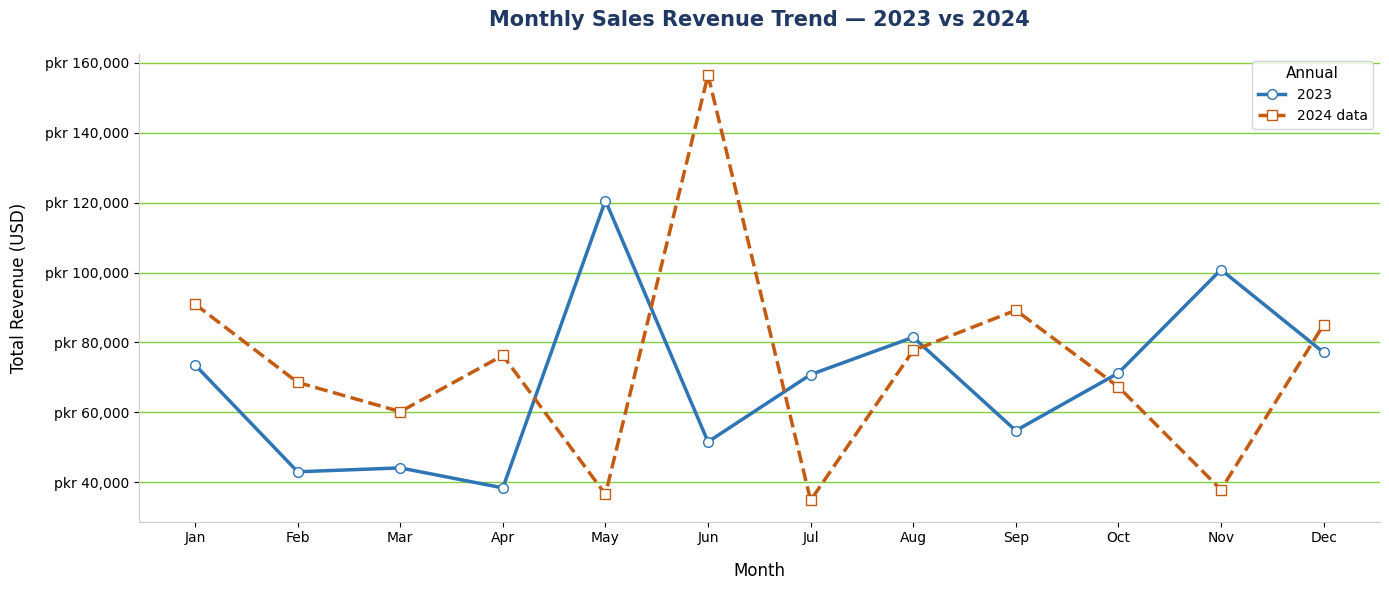

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ── Load data ──────
sheets = pd.read_excel('TechCorp_Cleaned.xlsx', sheet_name=None)
sales  = sheets['Sales']
sales['date'] = pd.to_datetime(sales['date'])

# ── Prepare data ──────
# Add year and month columns
sales['sale_year']  = sales['date'].dt.year
sales['sale_month'] = sales['date'].dt.month

# Group by year and month
monthly = (sales.groupby(['sale_year', 'sale_month'])['total_revenue']
                .sum()
                .reset_index()
                .sort_values(['sale_year', 'sale_month']))

# Separate 2023 and 2024
rev_2023 = monthly[monthly['sale_year'] == 2023]
rev_2024 = monthly[monthly['sale_year'] == 2024]

month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

# ── Build the chart ─────────
fig, ax = plt.subplots(figsize=(14, 6))

# 2023 line
ax.plot(
    rev_2023['sale_month'],
    rev_2023['total_revenue'],
    color          = '#2E75B6',
    linewidth      = 2.5,
    linestyle      = '-',
    marker         = 'o',
    markersize     = 7,
    markerfacecolor= 'white',
    markeredgecolor= '#2E75B6',
    label          = '2023'
)

# 2024 line
ax.plot(
    rev_2024['sale_month'],
    rev_2024['total_revenue'],
    color          = '#C55A11',
    linewidth      = 2.5,
    linestyle      = '--',
    marker         = 's',
    markersize     = 7,
    markerfacecolor= 'white',
    markeredgecolor= '#C55A11',
    label          = '2024 data'
)

# ── Formatting ────────────────────────────────────────────────────────────
ax.set_title('Monthly Sales Revenue Trend — 2023 vs 2024',
             fontsize=15, fontweight='bold', color='#1F3864', pad=20)
ax.set_xlabel('Month',   fontsize=12, labelpad=12)
ax.set_ylabel('Total Revenue (USD)', fontsize=12, labelpad=12)

# Replace month numbers with month names on x-axis
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_names, fontsize=10)

# Format y-axis as currency
ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f'pkr {x:,.0f}')
)

# Clean up spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')

# Grid — horizontal only
ax.yaxis.grid(True, color="#84CE3E", linewidth=1)
ax.set_axisbelow(True)

# Legend
ax.legend(title='Annual', fontsize=10, title_fontsize=11,
          frameon=True, edgecolor='#CCCCCC')

plt.tight_layout()
plt.show()

In [16]:
# fig.savefig('techcorp_revenue_trend.png', dpi=300,
#             bbox_inches='tight', facecolor='white')

**2. Bar Chart**

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ── Load data ─────────────────────────────────────────────────────────────
sheets = pd.read_excel('TechCorp_Cleaned.xlsx', sheet_name=None)
emp    = sheets['Employees']

# ── Prepare data ──────────────────────────────────────────────────────────
# Count employees per department, sorted highest to lowest
headcount = (emp.groupby('department')
                .size()
                .rename('headcount')
                .sort_values(ascending=False)
                .reset_index())

print(headcount)

         department  headcount
0       Engineering         25
1             Sales         24
2  Customer Support         19
3           Finance         18
4                HR         17
5         Marketing         17


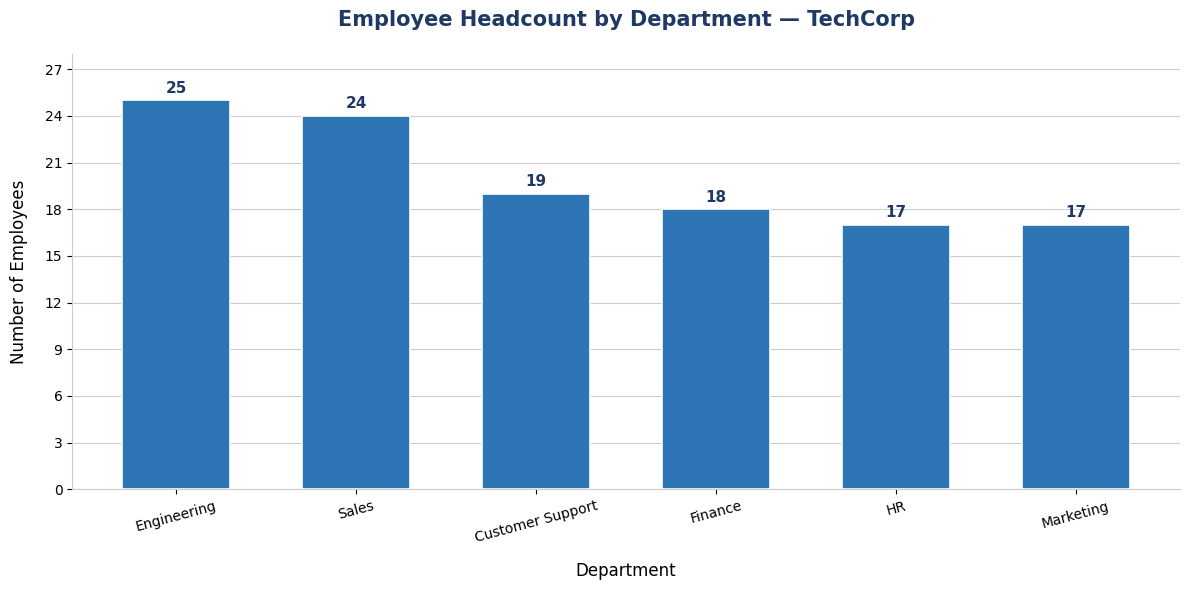

In [18]:
# ── Build the chart ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))

# Draw the bars
bars = ax.bar(
    headcount['department'],
    headcount['headcount'],
    color     = '#2E75B6',
    width     = 0.6,
    edgecolor = 'white',
    linewidth = 1.2,
    zorder    = 2
)

# ── Add data labels on top of each bar ───────────────────────────────────
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,  # x → centre of bar
        height + 0.3,                        # y → just above the bar top
        str(int(height)),                    # label text → the number
        ha       = 'center',
        va       = 'bottom',
        fontsize = 11,
        fontweight = 'bold',
        color    = '#1F3864'
    )

# ── Formatting ────────────────────────────────────────────────────────────
ax.set_title('Employee Headcount by Department — TechCorp',
             fontsize=15, fontweight='bold', color='#1F3864', pad=20)
ax.set_xlabel('Department',       fontsize=12, labelpad=12)
ax.set_ylabel('Number of Employees', fontsize=12, labelpad=12)

# Y-axis — start at 0, go a little above max value for label space
ax.set_ylim(0, headcount['headcount'].max() + 3)

# Only show whole numbers on y-axis
ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))

# Clean up spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')

# Horizontal grid lines only
ax.yaxis.grid(True, color='#CCCCCC', linewidth=0.8)
ax.set_axisbelow(True)

# Rotate x-axis labels slightly so they don't overlap
ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

In [19]:
# fig.savefig('techcorp_headcount.png', dpi=300,
#             bbox_inches='tight', facecolor='white')

**3. Horizontal Bar Chart**

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ── Load data ─────────────────────────────────────────────────────────────
sheets = pd.read_excel('TechCorp_Cleaned.xlsx', sheet_name=None)
emp    = sheets['Employees']

# ── Prepare data ──────────────────────────────────────────────────────────
dept_salary = (emp.groupby('department')['salary']
                  .mean()
                  .round(2)
                  .sort_values(ascending=True)   # ascending so largest ends up on top
                  .reset_index())

print(dept_salary)

         department     salary
0             Sales   90780.64
1                HR   93901.71
2  Customer Support   96917.14
3       Engineering   99261.37
4         Marketing  101631.97
5           Finance  106674.74


In [21]:
# ── Colour coding — highlight Engineering separately ──────────────────────
colors = ['#2E75B6' if dept != 'Engineering'
          else '#C55A11'
          for dept in dept_salary['department']]

C:\Users\hp\AppData\Local\Temp\ipykernel_19628\3902587646.py:44: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=10, frameon=True, edgecolor='#CCCCCC')


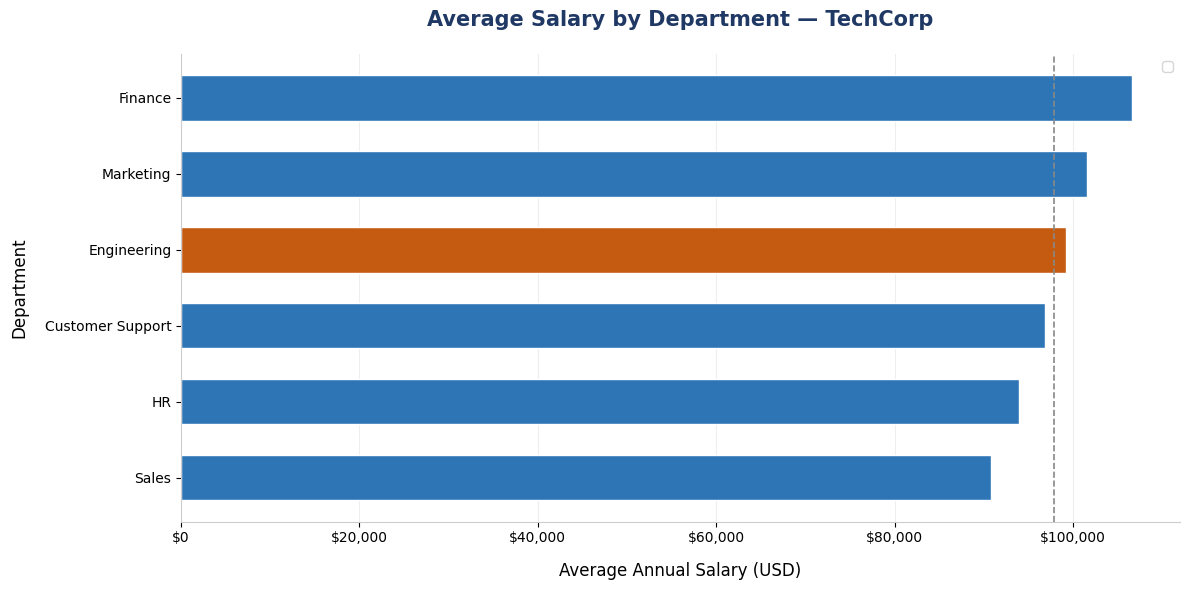

In [24]:
# ── Build the chart ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.barh(
    dept_salary['department'],   # y-axis → department names
    dept_salary['salary'],       # width  → average salary value
    height    = 0.6,             # bar thickness
    color     = colors,          # our custom colour list
    edgecolor = 'white',
    linewidth = 1.0,
    zorder    = 2
)

# ── Reference line — company average salary ───────────────────────────────
company_avg = emp['salary'].mean()
ax.axvline(
    x         = company_avg,
    color     = '#888888',
    linewidth = 1.2,
    linestyle = '--'
)

# ── Formatting ────────────────────────────────────────────────────────────
ax.set_title('Average Salary by Department — TechCorp',
             fontsize=15, fontweight='bold', color='#1F3864', pad=20)
ax.set_xlabel('Average Annual Salary (USD)', fontsize=12, labelpad=12)
ax.set_ylabel('Department',                  fontsize=12, labelpad=12)

# X-axis as currency
ax.xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f'${x:,.0f}')
)

# Clean up spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')

# Vertical grid lines only (since bars are horizontal)
ax.xaxis.grid(True, color='#EEEEEE', linewidth=0.8)
ax.set_axisbelow(True)

ax.legend(fontsize=10, frameon=True, edgecolor='#CCCCCC')

plt.tight_layout()
plt.show()

**4. Stacked Bar Chart**

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

sheets = pd.read_excel('TechCorp_Cleaned.xlsx', sheet_name=None)
sales  = sheets['Sales']
sales['date'] = pd.to_datetime(sales['date'])
sales['sale_year'] = sales['date'].dt.year

# Group by region and year
region_year = (sales.groupby(['region', 'sale_year'])['total_revenue']
                    .sum()
                    .round(2)
                    .reset_index())


# Separate 2023 and 2024
rev_2023 = region_year[region_year['sale_year'] == 2023].set_index('region')
rev_2024 = region_year[region_year['sale_year'] == 2024].set_index('region')


# # Define region order — sorted by combined total, largest first
region_order = (rev_2023['total_revenue'] + rev_2024['total_revenue']) \
                .sort_values(ascending=False).index.tolist()

# # Reindex both to match the same region order
rev_2023 = rev_2023.reindex(region_order)
rev_2024 = rev_2024.reindex(region_order)

print("2023 Revenue:\n", rev_2023['total_revenue'])
print("\n2024 Revenue:\n", rev_2024['total_revenue'])

2023 Revenue:
 region
North America    183927.72
Africa           195998.38
Europe           147793.25
Asia             149275.18
Middle East      150462.38
Name: total_revenue, dtype: float64

2024 Revenue:
 region
North America    207890.91
Africa           186223.65
Europe           200748.30
Asia             154026.25
Middle East      132071.51
Name: total_revenue, dtype: float64


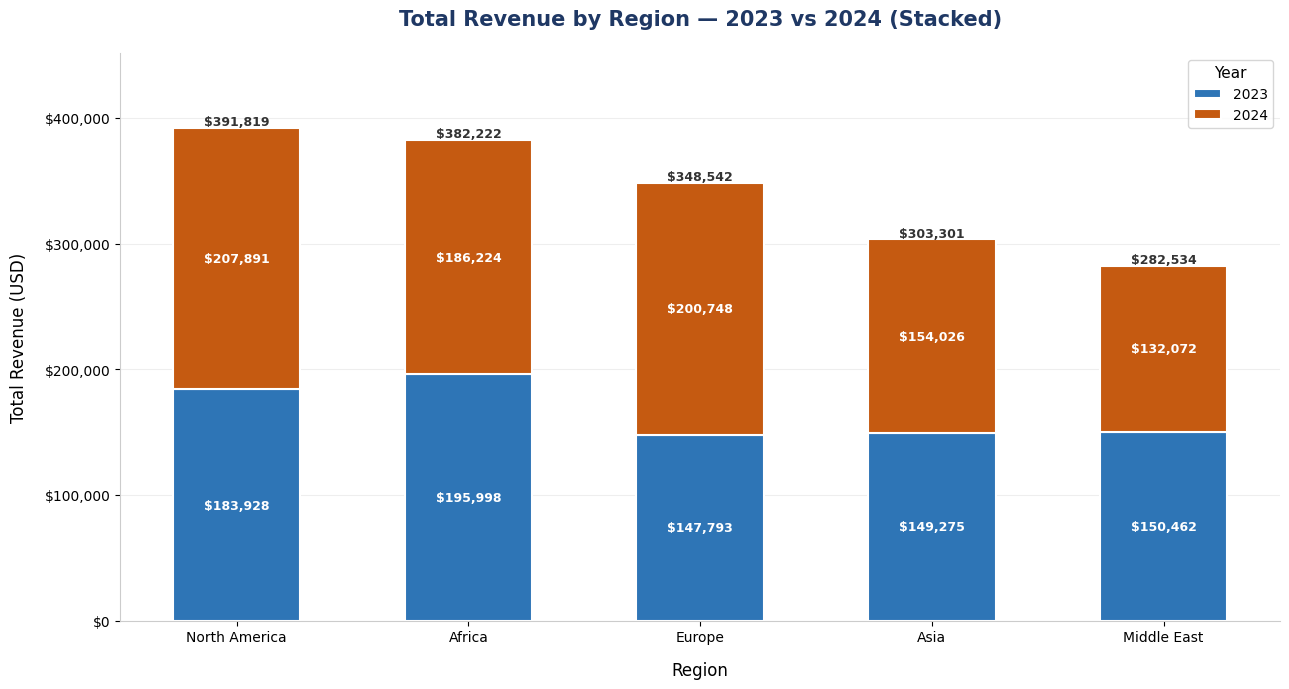

In [43]:
fig, ax = plt.subplots(figsize=(13, 7))

x = range(len(region_order))

# ── Draw 2023 segment first — starts at 0 (bottom) ───────────────────────
bars_2023 = ax.bar(
    x,
    rev_2023['total_revenue'],
    width     = 0.55,
    color     = '#2E75B6',
    edgecolor = 'white',
    linewidth = 1.5,
    label     = '2023',
    zorder    = 2
)

# ── Draw 2024 segment — starts at top of 2023 (bottom=rev_2023) ──────────
bars_2024 = ax.bar(
    x,
    rev_2024['total_revenue'],
    width     = 0.55,
    bottom    = rev_2023['total_revenue'],   # ← THIS is what creates stacking
    color     = '#C55A11',
    edgecolor = 'white',
    linewidth = 1.5,
    label     = '2024',
    zorder    = 2
)

# ── Data labels inside each segment ──────────────────────────────────────
for i, (b23, b24) in enumerate(zip(bars_2023, bars_2024)):

    # Label for 2023 segment — centred inside the segment
    h23 = b23.get_height()
    ax.text(
        b23.get_x() + b23.get_width() / 2,
        h23 / 2,                             # vertical centre of 2023 segment
        f'${h23:,.0f}',
        ha='center', va='center',
        fontsize=9, color='white', fontweight='bold'
    )

    # Label for 2024 segment — centred inside the segment
    h24 = b24.get_height()
    base = b24.get_y()                       # where 2024 segment starts
    ax.text(
        b24.get_x() + b24.get_width() / 2,
        base + h24 / 2,                      # vertical centre of 2024 segment
        f'${h24:,.0f}',
        ha='center', va='center',
        fontsize=9, color='white', fontweight='bold'
    )

    # Total label on top of the full bar
    total = h23 + h24
    ax.text(
        b23.get_x() + b23.get_width() / 2,
        total + 5000,                        # just above the bar top
        f'${total:,.0f}',
        ha='center', va='center',
        fontsize=9, color='#333333', fontweight='bold'
    )

# ── Formatting ────────────────────────────────────────────────────────────
ax.set_title('Total Revenue by Region — 2023 vs 2024 (Stacked)',
             fontsize=15, fontweight='bold', color='#1F3864', pad=20)
ax.set_xlabel('Region',              fontsize=12, labelpad=12)
ax.set_ylabel('Total Revenue (USD)', fontsize=12, labelpad=12)

# Replace x positions with region names
ax.set_xticks(list(x))
ax.set_xticklabels(region_order, fontsize=10)

# Y-axis as currency
ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f'${x:,.0f}')
)

# Add room above tallest bar for the total label
combined_max = (rev_2023['total_revenue'] + rev_2024['total_revenue']).max()
ax.set_ylim(0, combined_max + 60000)

# Clean spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')

# Horizontal grid
ax.yaxis.grid(True, color='#EEEEEE', linewidth=0.8)
ax.set_axisbelow(True)

ax.legend(title='Year', fontsize=10, title_fontsize=11,
          frameon=True, edgecolor='#CCCCCC')

plt.tight_layout()
fig.savefig('techcorp_stacked_revenue.png', dpi=300,
            bbox_inches='tight', facecolor='white')
plt.show()

**5. Histogram**

In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# ── Load data ─────────────────────────────────────────────────────────────
sheets = pd.read_excel('TechCorp_Cleaned.xlsx', sheet_name=None)
emp    = sheets['Employees']

# ── Quick check before plotting ───────────────────────────────────────────
print(f"Salary range : ${emp['salary'].min():,.0f} → ${emp['salary'].max():,.0f}")
print(f"Mean salary  : ${emp['salary'].mean():,.0f}")
print(f"Median salary: ${emp['salary'].median():,.0f}")
print(f"Std deviation: ${emp['salary'].std():,.0f}")

Salary range : $40,186 → $149,830
Mean salary  : $97,883
Median salary: $101,239
Std deviation: $32,055


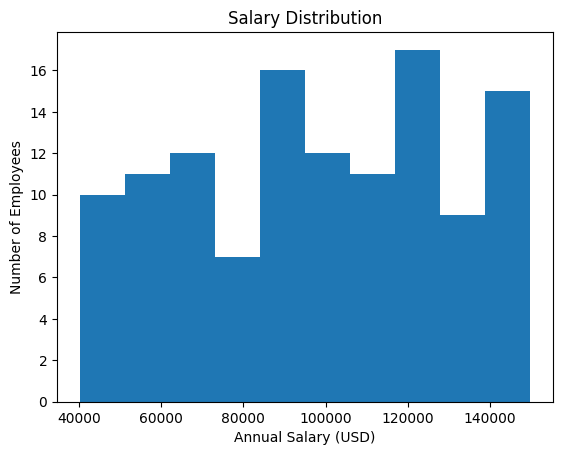

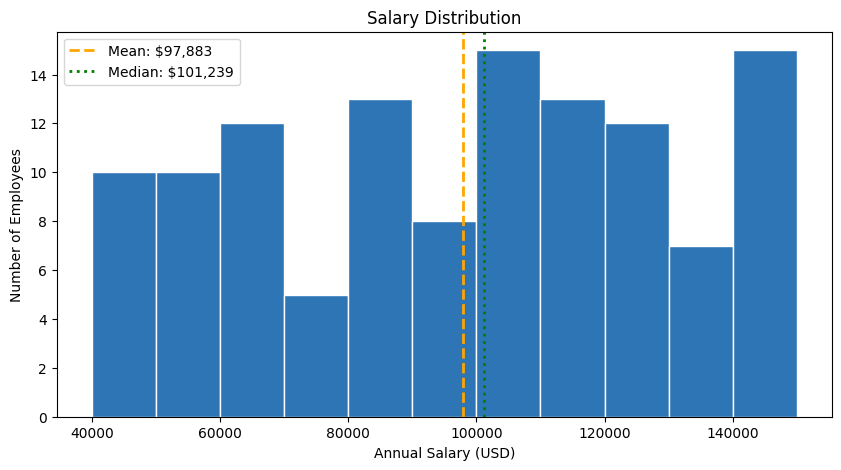

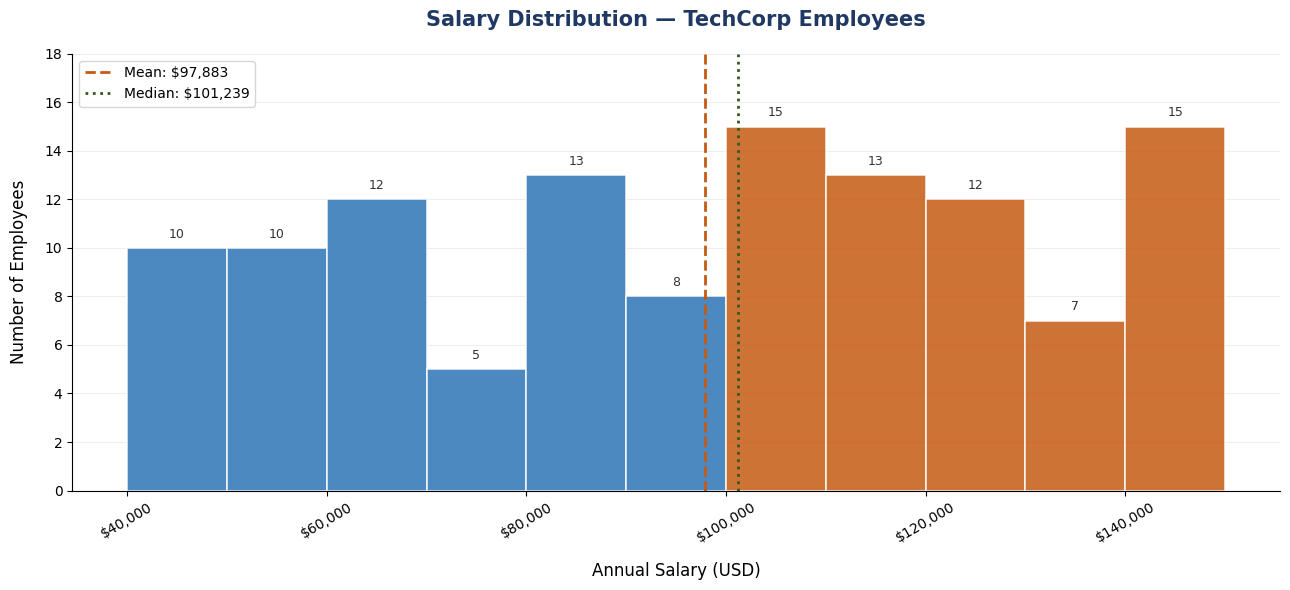

In [60]:
import pandas as pd
import matplotlib.pyplot as plt

# ── Load data (needed for every stage) ─────────────────────────────────────
sheets = pd.read_excel('TechCorp_Cleaned.xlsx', sheet_name=None)
emp = sheets['Employees']


# ============================================================================
# STAGE 1 — The bare minimum histogram
# ============================================================================
# Goal: just see a histogram exist. 5 real lines of plotting code.

fig, ax = plt.subplots()

ax.hist(emp['salary'])

ax.set_title('Salary Distribution')
ax.set_xlabel('Annual Salary (USD)')
ax.set_ylabel('Number of Employees')

plt.show()


# ============================================================================
# STAGE 2 — Control the bins, add reference lines
# ============================================================================
# New concepts introduced here:
#   1. Choosing the NUMBER of bins yourself (instead of matplotlib's default)
#   2. Using exact bin EDGES for clean round numbers on the x-axis
#   3. axvline() to draw a vertical line (e.g. mean, median)

import numpy as np  # needed for np.arange below

# 2a. Try a simple bin count first (uncomment to test):
# ax.hist(emp['salary'], bins=10)

# 2b. Then move to exact bin edges — cleaner x-axis labels
bin_edges = np.arange(40000, 160000, 10000)
# This creates: [40000, 50000, 60000, ... 150000]
# Each bin covers a $10,000 salary range

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(
    emp['salary'],
    bins=bin_edges,
    color='#2E75B6',
    edgecolor='white'
)

# Add a vertical line at the mean salary
mean_salary = emp['salary'].mean()
ax.axvline(mean_salary, color='orange', linewidth=2, linestyle='--',
           label=f'Mean: ${mean_salary:,.0f}')

# Add a vertical line at the median salary
median_salary = emp['salary'].median()
ax.axvline(median_salary, color='green', linewidth=2, linestyle=':',
           label=f'Median: ${median_salary:,.0f}')

ax.set_title('Salary Distribution')
ax.set_xlabel('Annual Salary (USD)')
ax.set_ylabel('Number of Employees')
ax.legend()

plt.show()

# ============================================================================
# STAGE 3 — Polish (for advanced learners / once Stage 2 feels comfortable)
# ============================================================================
# New concepts introduced here:
#   1. ax.hist() returns (n, bins, patches) — patches are the bar objects
#   2. Looping over patches to recolor bars conditionally
#   3. ax.text() to label each bar with its count (ha/va anchoring)
#   4. ticker.FuncFormatter to format axis tick labels as currency

import matplotlib.ticker as ticker

fig, ax = plt.subplots(figsize=(13, 6))

# hist() gives us back n (counts), bins (edges), and patches (the bar shapes)
n, bins_out, patches = ax.hist(
    emp['salary'],
    bins=bin_edges,
    color='#2E75B6',
    edgecolor='white',
    linewidth=1.2,
    alpha=0.85
)

mean_salary = emp['salary'].mean()

# Recolor bars that start at or above the mean
for patch, left_edge in zip(patches, bins_out[:-1]):
    if left_edge >= mean_salary:
        patch.set_facecolor('#C55A11')  # orange

ax.axvline(mean_salary, color='#C55A11', linewidth=2, linestyle='--',
           label=f'Mean: ${mean_salary:,.0f}')

median_salary = emp['salary'].median()
ax.axvline(median_salary, color='#375623', linewidth=2, linestyle=':',
           label=f'Median: ${median_salary:,.0f}')

# Label each bar with its count, just above the bar top
for count, patch in zip(n, patches):
    if count > 0:
        ax.text(
            patch.get_x() + patch.get_width() / 2,  # x = center of bar
            count + 0.3,                             # y = just above bar top
            str(int(count)),
            ha='center', va='bottom',
            fontsize=9, color='#333333'
        )

ax.set_title('Salary Distribution — TechCorp Employees',
             fontsize=15, fontweight='bold', color='#1F3864', pad=20)
ax.set_xlabel('Annual Salary (USD)', fontsize=12, labelpad=12)
ax.set_ylabel('Number of Employees', fontsize=12, labelpad=12)

# Format x-axis ticks as currency, e.g. $40,000
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.tick_params(axis='x', rotation=30)
ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))

ax.set_ylim(0, n.max() + 3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, color='#EEEEEE', linewidth=0.8)
ax.set_axisbelow(True)

ax.legend(fontsize=10, frameon=True, edgecolor='#CCCCCC')

plt.tight_layout()
plt.show()



**6. Scatter plot**

C:\Users\hp\AppData\Local\Temp\ipykernel_19628\2780482225.py:29: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  axes[1, 2].scatter(x, y, s=200, c=['red', 'blue', 'red', 'green', 'blue'], cmap='viridis')


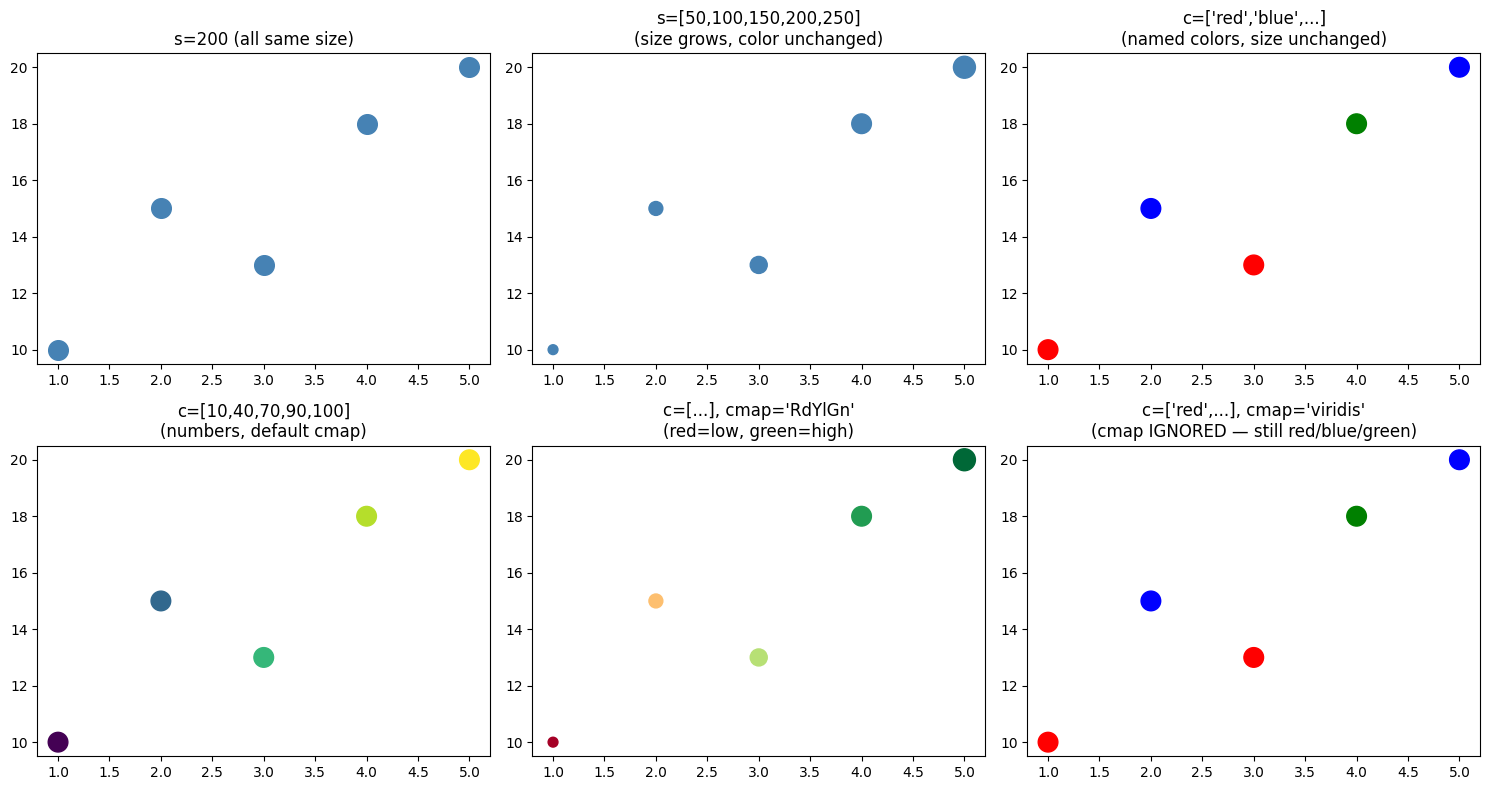

In [62]:
import matplotlib.pyplot as plt

x = [1, 2, 3, 4, 5]
y = [10, 15, 13, 18, 20]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# ── 1. s: single number → all dots same size ───────────────────────────────
axes[0, 0].scatter(x, y, s=200, c='steelblue')
axes[0, 0].set_title('s=200 (all same size)')

# ── 2. s: array → each dot sized differently ───────────────────────────────
axes[0, 1].scatter(x, y, s=[50, 100, 150, 200, 250], c='steelblue')
axes[0, 1].set_title('s=[50,100,150,200,250]\n(size grows, color unchanged)')

# ── 3. c: named colors per dot → no cmap needed ────────────────────────────
axes[0, 2].scatter(x, y, s=200, c=['red', 'blue', 'red', 'green', 'blue'])
axes[0, 2].set_title("c=['red','blue',...]\n(named colors, size unchanged)")

# ── 4. c: numbers, NO cmap specified → matplotlib picks a default gradient ─
sc4 = axes[1, 0].scatter(x, y, s=200, c=[10, 40, 70, 90, 100])
axes[1, 0].set_title('c=[10,40,70,90,100]\n(numbers, default cmap)')

# ── 5. c: numbers + cmap='RdYlGn' → red=low, green=high ───────────────────
sc5 = axes[1, 1].scatter(x, y, s=[50, 100, 150, 200, 250], c=[10, 40, 70, 90, 100], cmap='RdYlGn')
axes[1, 1].set_title("c=[...], cmap='RdYlGn'\n(red=low, green=high)")

# ── 6. c is COLOR NAMES + cmap → cmap is silently IGNORED ──────────────────
axes[1, 2].scatter(x, y, s=200, c=['red', 'blue', 'red', 'green', 'blue'], cmap='viridis')
axes[1, 2].set_title("c=['red',...], cmap='viridis'\n(cmap IGNORED — still red/blue/green)")

plt.tight_layout()
plt.show()

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ── Load data ─────────────────────────────────────────────────────────────
sheets = pd.read_excel('TechCorp_Cleaned.xlsx', sheet_name=None)
emp    = sheets['Employees']
emp['hire_date'] = pd.to_datetime(emp['hire_date'])

# ── Quick check ───────────────────────────────────────────────────────────
print(f"Correlation between salary and rating: "
      f"{emp['salary'].corr(emp['performance_rating']):.3f}")

Correlation between salary and rating: 0.062


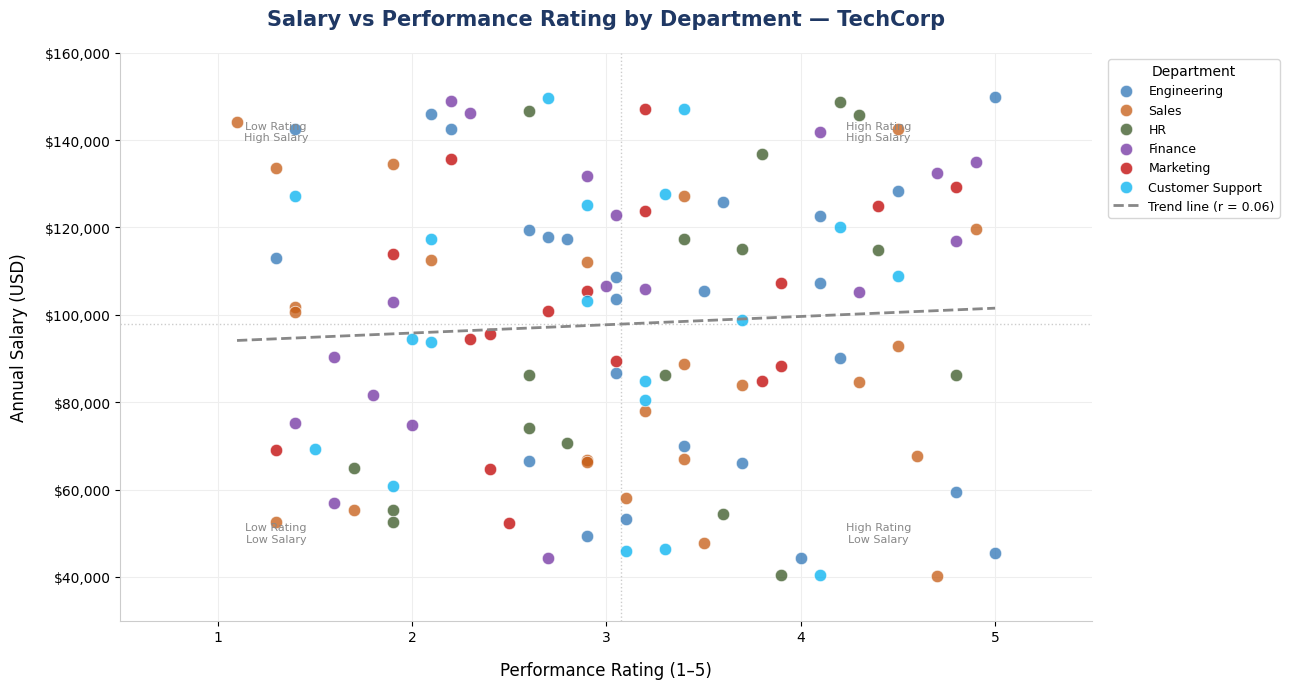

In [66]:
# ── Colour map — one colour per department ────────────────────────────────
departments = emp['department'].unique()
colour_map  = {
    'Engineering'     : '#2E75B6',
    'Sales'           : '#C55A11',
    'HR'              : '#375623',
    'Finance'         : '#7030A0',
    'Marketing'       : '#C00000',
    'Customer Support': '#00B0F0'
}
emp['dot_color'] = emp['department'].map(colour_map)

# ── Build the chart ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 7))

# ── Plot each department separately so legend works correctly ─────────────
for dept, color in colour_map.items():
    subset = emp[emp['department'] == dept]
    ax.scatter(
        subset['performance_rating'],
        subset['salary'],
        s          = 80,
        c          = color,
        alpha      = 0.75,
        edgecolors = 'white',
        linewidths = 0.6,
        marker     = 'o',
        label      = dept,
        zorder     = 2
    )
    # ── Add a trend line ──────────────────────────────────────────────────────
# Drop NaN values before fitting
clean = emp.dropna(subset=['performance_rating', 'salary'])

# Fit a straight line through the points (degree 1 polynomial)
m, b = np.polyfit(clean['performance_rating'], clean['salary'], deg=1)

# Create x values across the full rating range
x_line = np.linspace(
    clean['performance_rating'].min(),
    clean['performance_rating'].max(),
    100
)
y_line = m * x_line + b

# Draw the trend line
ax.plot(
    x_line, y_line,
    color     = '#888888',
    linewidth = 2,
    linestyle = '--',
    label     = f'Trend line (r = {clean["salary"].corr(clean["performance_rating"]):.2f})',
    zorder    = 3
)

# ── Add quadrant reference lines ──────────────────────────────────────────
# These divide the chart into 4 zones based on avg salary and avg rating
avg_rating = clean['performance_rating'].mean()
avg_salary = clean['salary'].mean()

ax.axvline(avg_rating, color='#CCCCCC', linewidth=1,
           linestyle=':', zorder=1)
ax.axhline(avg_salary, color='#CCCCCC', linewidth=1,
           linestyle=':', zorder=1)

# Label the four quadrants
ax.text(4.4, 140000, 'High Rating\nHigh Salary',
        fontsize=8, color='#888888', ha='center')
ax.text(1.3, 140000, 'Low Rating\nHigh Salary',
        fontsize=8, color='#888888', ha='center')
ax.text(4.4, 48000,  'High Rating\nLow Salary',
        fontsize=8, color='#888888', ha='center')
ax.text(1.3, 48000,  'Low Rating\nLow Salary',
        fontsize=8, color='#888888', ha='center')

# ── Formatting ────────────────────────────────────────────────────────────
ax.set_title('Salary vs Performance Rating by Department — TechCorp',
             fontsize=15, fontweight='bold', color='#1F3864', pad=20)
ax.set_xlabel('Performance Rating (1–5)', fontsize=12, labelpad=12)
ax.set_ylabel('Annual Salary (USD)',       fontsize=12, labelpad=12)

# Y-axis as currency
ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f'${x:,.0f}')
)

# X-axis limits — give breathing room on both sides of the rating scale
ax.set_xlim(0.5, 5.5)
ax.set_ylim(30000, 160000)

# Clean spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')

# Light grid
ax.yaxis.grid(True, color='#EEEEEE', linewidth=0.8)
ax.xaxis.grid(True, color='#EEEEEE', linewidth=0.8)
ax.set_axisbelow(True)

# Legend — place outside the chart area so it doesn't cover dots
ax.legend(title='Department', fontsize=9, title_fontsize=10,
          frameon=True, edgecolor='#CCCCCC',
          bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
fig.savefig('techcorp_scatter_salary_rating.png', dpi=300,
            bbox_inches='tight', facecolor='white')
plt.show()

**7. Pie Chart**

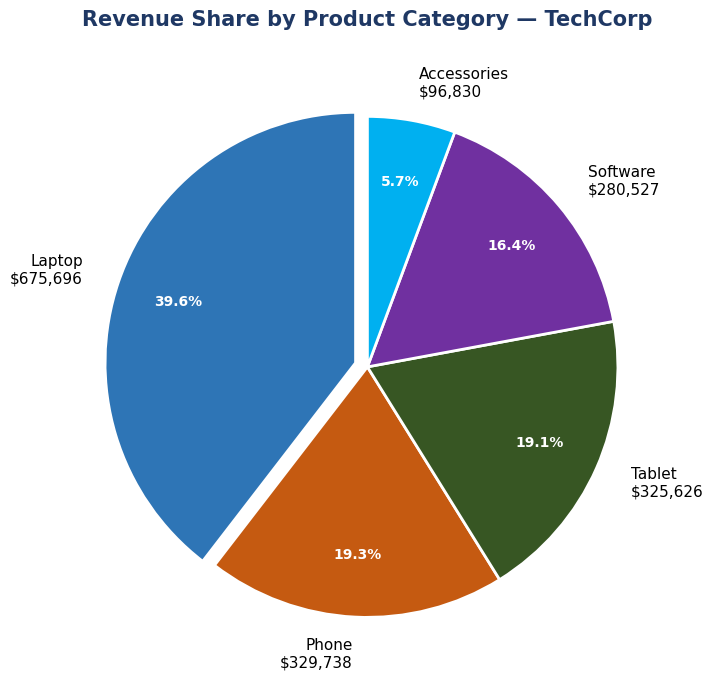

In [72]:
import pandas as pd
import matplotlib.pyplot as plt

# ── Load data ─────────────────────────────────────────────────────────────
sheets = pd.read_excel('TechCorp_Cleaned.xlsx', sheet_name=None)
sales  = sheets['Sales']
prod   = sheets['Products']

sales_prod = sales.merge(prod[['product_id', 'category']],
                          on='product_id', how='left')

cat_revenue = (sales_prod.groupby('category')['total_revenue']
                          .sum()
                          .sort_values(ascending=False)
                          .reset_index())

# ── Build combined labels: category name + dollar value together ──────────
labels = [f'{cat}\n${rev:,.0f}' for cat, rev in
          zip(cat_revenue['category'], cat_revenue['total_revenue'])]

# ── Colours and explode ────────────────────────────────────────────────────
colors  = ['#2E75B6', '#C55A11', '#375623', '#7030A0', '#00B0F0']
explode = [0.05, 0, 0, 0, 0]

# ── Build the chart ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))

wedges, texts, autotexts = ax.pie(
    cat_revenue['total_revenue'],
    labels        = labels,          # now includes name + $ value
    colors        = colors,
    autopct       = '%1.1f%%',
    pctdistance   = 0.75,
    explode       = explode,
    startangle    = 90,
    wedgeprops    = {'edgecolor': 'white', 'linewidth': 2},
    textprops     = {'fontsize': 11},
    labeldistance = 1.15
)

# ── Style the percentage labels inside the slices ─────────────────────────
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(10)

ax.set_title('Revenue Share by Product Category — TechCorp',
             fontsize=15, fontweight='bold', color='#1F3864', pad=20)

ax.set_aspect('equal')

plt.tight_layout()
fig.savefig('techcorp_pie_revenue.png', dpi=300,
            bbox_inches='tight', facecolor='white')
plt.show()

## Module 3: Matplotlib Styling & Customisation

**a. Color:**

**1. Named colors**

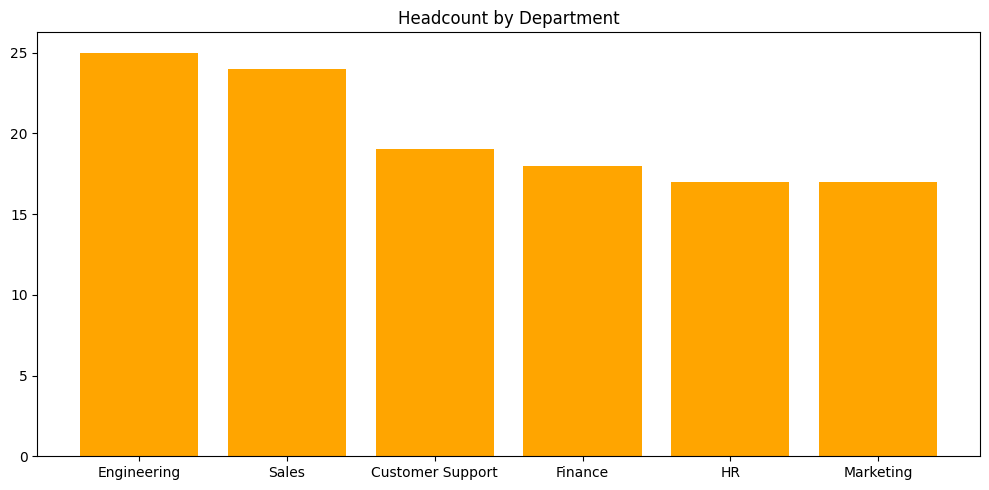

In [74]:
import pandas as pd
import matplotlib.pyplot as plt

sheets = pd.read_excel('TechCorp_Cleaned.xlsx', sheet_name=None)
emp    = sheets['Employees']

headcount = emp['department'].value_counts()

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(headcount.index, headcount.values, color='orange')
ax.set_title('Headcount by Department')
plt.tight_layout()
plt.show()

**2. Color codes:**

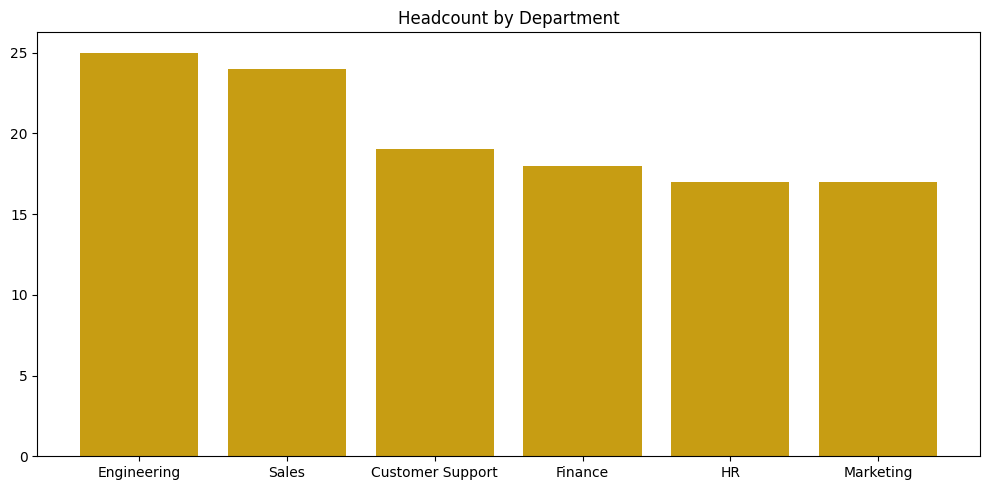

In [76]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(headcount.index, headcount.values, color="#C79D13")
ax.set_title('Headcount by Department')
plt.tight_layout()
plt.show()

**3. Color list (one color per bar)**

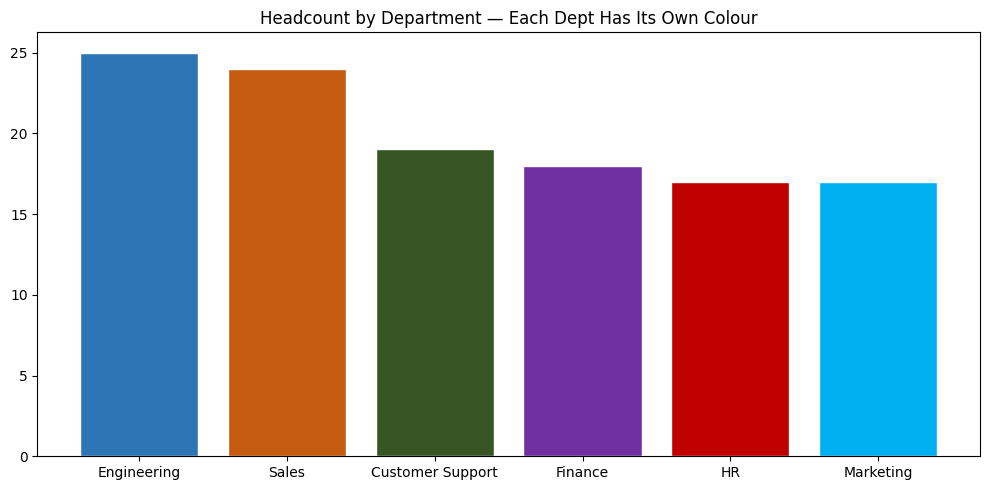

In [77]:
colors = ['#2E75B6','#C55A11','#375623',
          '#7030A0','#C00000','#00B0F0']

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(headcount.index, headcount.values,
       color=colors, edgecolor='white', linewidth=1)
ax.set_title('Headcount by Department — Each Dept Has Its Own Colour')
plt.tight_layout()
plt.show()

**4. Conditional Colors**

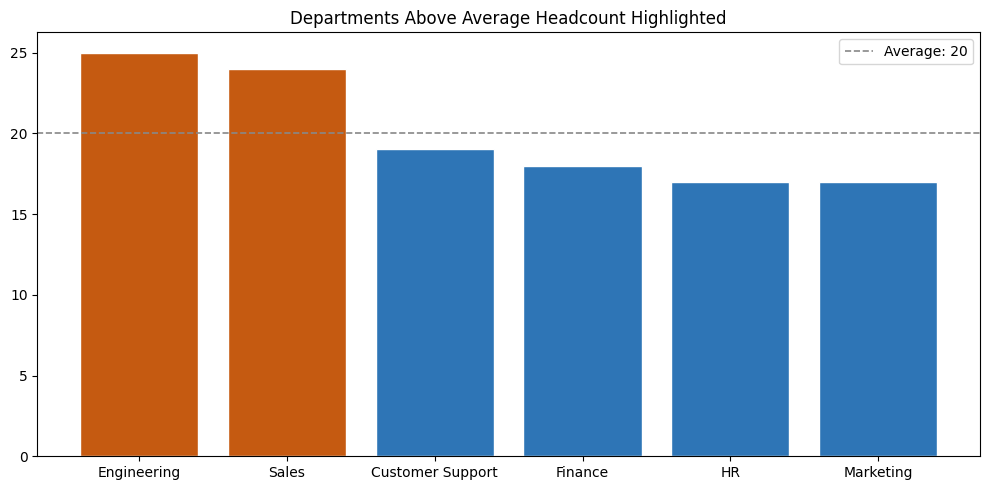

In [78]:
avg = headcount.mean()

colors = ['#C55A11' if v >= avg else '#2E75B6'
          for v in headcount.values]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(headcount.index, headcount.values,
       color=colors, edgecolor='white', linewidth=1)
ax.axhline(avg, color='#888888', linewidth=1.2,
           linestyle='--', label=f'Average: {avg:.0f}')
ax.set_title('Departments Above Average Headcount Highlighted')
ax.legend()
plt.tight_layout()
plt.show()

**5. Colormap**

C:\Users\hp\AppData\Local\Temp\ipykernel_19628\933791606.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap   = cm.get_cmap('Blues')


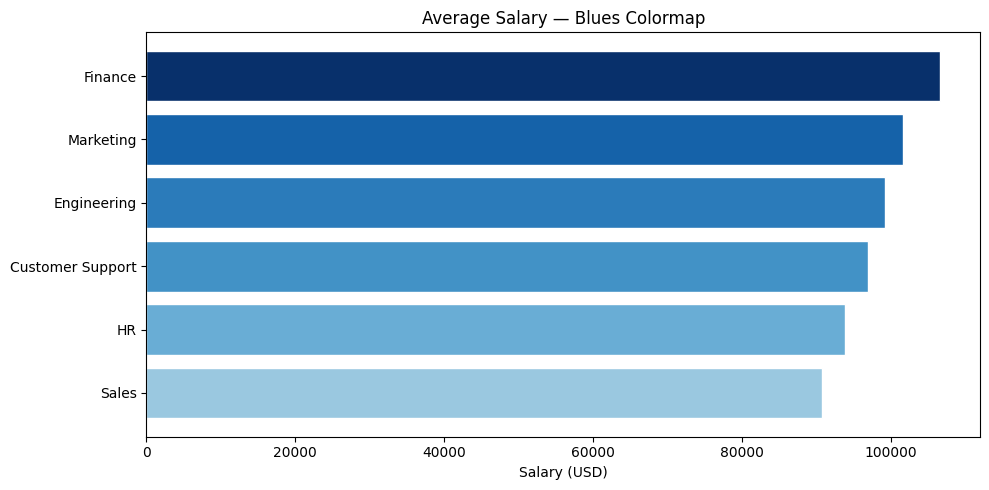

In [80]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors

dept_salary = (emp.groupby('department')['salary']
                  .mean().sort_values().reset_index())

norm   = mcolors.Normalize(vmin=dept_salary['salary'].min()-10000,
                            vmax=dept_salary['salary'].max())
cmap   = cm.get_cmap('Blues')
colors = [cmap(norm(v)) for v in dept_salary['salary']]

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(dept_salary['department'], dept_salary['salary'],
        color=colors, edgecolor='white', linewidth=1)
ax.set_title('Average Salary — Blues Colormap')
ax.set_xlabel('Salary (USD)')
plt.tight_layout()
plt.show()